# MDR-TS v17.1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v17.1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base_1.0/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

New split that includes the full 2023-2025 years in the test split. I shrunk down the size of the training split.

## 0. Imports

In [1]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

import torch

import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

imports loaded
using: cpu


In [2]:
SEED = 42
DEEP_SEARCH = 40

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


In [3]:
VERSION = "v17"
SUBVERSION = "v17.1"
RUN_NAME = "mdr_ts_v17_1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v17/v17.1

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


In [4]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_7.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_7.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_7.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_7.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_7.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_7.0/test.csv


In [5]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 495

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


In [6]:
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
        "SMAP_sm_pm_interp_ema02",
        "V_rollmin_LST_modis_kobs30",
        "D_sin_DOY",
        "G_rain_sum_3d",
        "V_ema_G_API_kobs7",
        "V_rollmin_G_API_kobs30",
        "G_rain_sum_7d",
        "C_lag_LST_modis_kobs30",
        "C_lag_G_API_kobs1",
        "V_ema_G_API_kobs14",
        "V_rollmean_G_API_kobs14",
        "G_API",
        "A_pct_G_API",
        "V_rollcv_G_API_kobs30",
        "G_DSLR",
        "SMAP_ampm_diff_interp",
        "V_rollmax_G_API_kobs30",
        "V_rollmin_G_API_kobs7",
        "V_ema_G_API_kobs30",
        "V_rollmean_s2_b11_kobs7",
        "V_ema_LST_modis_kobs7",
        "C_smm_G_API_alpha0.85_n5",
        "C_lag_G_API_kobs5",
        "V_rollmean_G_API_kobs7",
        "C_lag_s2_b11_kobs30",
        "D_z_LST_modis",
        "A_d_G_API_kobs1",
        "V_rollcv_LST_modis_kobs30",
        "V_rollcv_G_API_kobs7",
        "V_rollstd_LST_modis_kobs30",
        "A_d_E_SAR_diff_kobs14",
        "C_lag_G_API_kobs6",
        "V_rollrng_F_NDMI_kobs7",
        "V_rollcv_G_API_kobs14",
        "C_lag_LST_modis_kobs6",
        "A_d_E_SAR_diff_kobs30",
        "A_d_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollrange7",
        "V_rollstd_LST_modis_kobs14",
        "D_fft_ent_E_SAR_ratio_kobs30",
        "A_d_E_SAR_diff_kobs5",
        "SMAP_sm_pm_interp_rollrange7",
        "V_rollstd_F_NDMI_kobs7",
        "V_rollstd_E_SAR_ratio_kobs7",
        "V_rollrng_E_SAR_diff_kobs7",
        "V_rollstd_s2_b12_kobs7",
        "A_grad_E_SAR_diff_kobs14",
        "D_fft_dom_LST_modis_kobs30",
        "V_rollcv_s2_b12_kobs7",
        "A_d_E_SAR_ratio_kobs5",
        "D_fft_ent_LST_modis_kobs30",
        "V_rollstd_F_NDVI_kobs7",
        "A_grad_s2_b12_kobs7",
        "A_pct_F_NDVI",
        "A_d_s2_b12_kobs2",
        "A_grad_E_SAR_diff_kobs30",
        "A_d_F_NDVI_kobs2",
        "A_grad_E_SAR_diff_kobs7",
        "SMAP_sm_interp_rollrange7",
        "A_d_s2_b12_kobs7",
        "A_d_F_NDVI_kobs1",
        "V_rollcv_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollstd7",
        "V_rollstd_SMAP_sm_interp_kobs7",
        "A_d_s2_b12_kobs5",
        "A_pct_SMAP_sm_interp",
        "SMAP_sm_am_interp_pctchg",
        "V_rollrng_SMAP_sm_interp_kobs7",
        "SMAP_sm_interp_pctchg",
        "A_d_E_SAR_diff_kobs2",
        "G_DSLR_isnan",
        "SMAP_sm_pm_interp_mask",
        "SMAP_sm_interp_mask",
        "SMAP_sm_am_interp_mask",
        "SMAP_sm_am_interp_diff1",
        "SMAP_sm_interp_rollstd7",
        "SMAP_sm_interp_diff1",
        "V_rollstd_E_SAR_diff_kobs7",
        "A_grad_s2_b12_kobs14",
        "A_d_E_SAR_ratio_kobs7",
        "A_grad_LST_modis_kobs14",
        "A_d_SMAP_sm_interp_kobs1",
        "SMAP_sm_pm_interp_pctchg",
        "A_grad_E_SAR_ratio_kobs7",
        "A_d_E_SAR_diff_kobs1",
        "A_d_E_SAR_diff_kobs7",
        "SMAP_sm_pm_interp_diff1",
        "A_d_F_NDVI_kobs5",
        "A_d_E_SAR_ratio_kobs2",
        "A_d_G_API_kobs5",
        "A_d_SMAP_sm_interp_kobs2",
        "D_fft_dom_E_SAR_ratio_kobs30",
        "SMAP_sm_pm_interp_rollstd7",
        "V_rollrng_s2_b12_kobs7",
        "V_rollrng_F_NDVI_kobs7",
        "A_d_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_ratio",
        "V_rollstd_SMAP_sm_interp_kobs30",
        "A_d_E_SAR_ratio_kobs1",
        "A_pct_LST_modis",
        "A_grad_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_diff",
        "SMAP_sm_interp_grad7",
        "A_grad_SMAP_sm_interp_kobs7",
        "A_d_LST_modis_kobs1",
        "V_rollcv_E_SAR_diff_kobs7",
        "A_d_s2_b11_kobs5",
        "V_rollstd_LST_modis_kobs7",

        # drift
        'year_frac',
        'sin_year',
        'cos_year',
        'API_x_year',
        'SMAP_x_year',


        # spatial
        "slope",
        "elev",
        "K_slope_sin",
        "K_slope_cos",
        "K_aspect_cos",

        "J_clay_wfrac_b0",
        "J_sand_wfrac_b0",
        "J_sand_clay_ratio_b0",

]

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 121
  Target:   soil_moisture_5cm


In [7]:
def metrics_block(y_true, y_pred, name="Test", tol=None, prefix=""):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    err = y_true - y_pred
    ae = np.abs(err)

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)

    bias = float(np.mean(err))
    err_std = float(np.std(err, ddof=0))
    debiased_std = float(np.std(err - bias, ddof=0))

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        corr = np.nan
    else:
        corr = float(np.corrcoef(y_true, y_pred)[0, 1])

    q_err = np.quantile(err, [0.05, 0.25, 0.50, 0.75, 0.95])
    med_ae = float(np.median(ae))
    p90_ae = float(np.quantile(ae, 0.90))

    print(f"{name}")
    print(f"{prefix}n    = {len(y_true)}")
    print(f"{prefix}R2   = {float(r2):.5f}")
    print(f"{prefix}MAE  = {float(mae):.5f}")
    print(f"{prefix}RMSE = {float(rmse):.5f}")
    print(f"{prefix}Bias (true-pred)  = {bias:.5f}")
    print(f"{prefix}Err std           = {err_std:.5f}")
    print(f"{prefix}Err std (debiased)= {debiased_std:.5f}")
    print(f"{prefix}Pearson r         = {corr:.5f}")
    print(f"{prefix}Median |err|      = {med_ae:.5f}")
    print(f"{prefix}P90 |err|         = {p90_ae:.5f}")
    print(f"{prefix}err quantiles [5/25/50/75/95%] = "
          f"{q_err[0]:.5f}, {q_err[1]:.5f}, {q_err[2]:.5f}, {q_err[3]:.5f}, {q_err[4]:.5f}")

    if tol is not None:
        tols = tol if isinstance(tol, (list, tuple, np.ndarray)) else [tol]
        for t in tols:
            frac = float(np.mean(ae <= t))
            print(f"{prefix}Within ±{t}: {frac:.3%}")

    return {
        "n": int(len(y_true)),
        "r2": float(r2),
        "mae": float(mae),
        "rmse": float(rmse),
        "bias_true_minus_pred": float(bias),
        "err_std": float(err_std),
        "err_std_debiased": float(debiased_std),
        "pearson_r": float(corr),
        "median_abs_err": float(med_ae),
        "p90_abs_err": float(p90_ae),
        "err_q05": float(q_err[0]),
        "err_q25": float(q_err[1]),
        "err_q50": float(q_err[2]),
        "err_q75": float(q_err[3]),
        "err_q95": float(q_err[4]),
    }

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [8]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     10424
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2014-01-01 -- 2019-12-31

VAL
  rows:     4449
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2020-01-01 -- 2022-12-31

TEST
  rows:     4016
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-01-01 -- 2025-12-31

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']

-- split locked --


In [9]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

trainval_df_d["date"] = pd.to_datetime(trainval_df_d["date"], errors="coerce")
trainval_df_d["year"] = trainval_df_d["date"].dt.year.astype(float)

max_year = trainval_df_d["year"].max()
beta = 0.2

w_trainval = np.exp(beta * (trainval_df_d["year"] - max_year))
w_trainval = w_trainval / w_trainval.mean()

In [10]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_trainval_d = trainval_df_d[FEATURE_COLS].copy()
y_trainval_d = trainval_df_d[TARGET_COL].copy()

X_test_d = test_df[FEATURE_COLS].copy()
y_test_d = test_df[TARGET_COL].copy()

print("\nDRIFT matrices:")
print("  X_trainval_d:", X_trainval_d.shape)
print("  X_test_d:    ", X_test_d.shape)


DRIFT matrices:
  X_trainval_d: (14873, 121)
  X_test_d:     (4016, 121)


### Drift Model (No Weights)

In [11]:
XGB_PARAMS_DRIFT_NO_W = dict(
    objective="reg:absoluteerror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

In [12]:
w_trainval_s = pd.Series(w_trainval)
years_tv = trainval_df_d["year"].reset_index(drop=True)

print("Weight stats:")
print(w_trainval_s.describe())

min_year = years_tv.min()
max_year = years_tv.max()

print("Min year weight:", float(w_trainval_s[years_tv == min_year].mean()))
print("Max year weight:", float(w_trainval_s[years_tv == max_year].mean()))

Weight stats:
count    14873.000000
mean         1.000000
std          0.501652
min          0.411805
25%          0.614341
50%          0.916489
75%          1.367240
max          2.039683
Name: year, dtype: float64
Min year weight: 0.4118048968857428
Max year weight: 2.039683006799771


In [13]:
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

xgb_drift_no_w_tv = XGBRegressor(**XGB_PARAMS_DRIFT_NO_W)
xgb_drift_no_w_tv.fit(
  trainval_df_d[FEATURE_COLS],
  trainval_df_d[TARGET_COL],
  verbose=0,
  )

y_test_d = np.asarray(test_df[TARGET_COL]).ravel()
pred_drift_test_no_w = np.asarray(xgb_drift_no_w_tv.predict(test_df[FEATURE_COLS])).ravel()

In [20]:
_ = metrics_block(y_test_d, pred_drift_test_no_w, name="=== DRIFT (no WEIGHTS) Test ===", tol=[0.02, 0.05, 0.10])

=== DRIFT (no WEIGHTS) Test ===
n    = 4016
R2   = 0.81424
MAE  = 0.03005
RMSE = 0.04058
Bias (true-pred)  = -0.00400
Err std           = 0.04039
Err std (debiased)= 0.04039
Pearson r         = 0.90351
Median |err|      = 0.02247
P90 |err|         = 0.06527
err quantiles [5/25/50/75/95%] = -0.07372, -0.02499, -0.00430, 0.01914, 0.05758
Within ±0.02: 45.468%
Within ±0.05: 82.644%
Within ±0.1: 96.738%


### Drift Model (With Weights)

In [15]:
XGB_PARAMS_DRIFT_W = dict(
    objective="reg:pseudohubererror",
    random_state=SEED,
    n_jobs=-1,
    subsample=0.9,
    colsample_bytree=0.8,
    max_depth=8,
    min_child_weight=2,
    n_estimators=5500,
    learning_rate=0.04,
    reg_lambda=1.5,
    reg_alpha=0.03,
    gamma=0.0,
)

In [16]:
trainval_df_d = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

xgb_drift_w_tv = XGBRegressor(**XGB_PARAMS_DRIFT_W)
xgb_drift_w_tv.fit(
  trainval_df_d[FEATURE_COLS],
  trainval_df_d[TARGET_COL],
  verbose=0,
  sample_weight=w_trainval
  )

y_test_d = np.asarray(test_df[TARGET_COL]).ravel()
pred_drift_test_w = np.asarray(xgb_drift_w_tv.predict(test_df[FEATURE_COLS])).ravel()



In [21]:
_ = metrics_block(y_test_d, pred_drift_test_w, name="=== DRIFT (WEIGHTED) Test ===", tol=[0.02, 0.05, 0.10])

=== DRIFT (WEIGHTED) Test ===
n    = 4016
R2   = 0.81910
MAE  = 0.02879
RMSE = 0.04005
Bias (true-pred)  = -0.00044
Err std           = 0.04005
Err std (debiased)= 0.04005
Pearson r         = 0.90509
Median |err|      = 0.02073
P90 |err|         = 0.06374
err quantiles [5/25/50/75/95%] = -0.06605, -0.02042, -0.00107, 0.02126, 0.06120
Within ±0.02: 48.705%
Within ±0.05: 83.416%
Within ±0.1: 96.863%


In [17]:
diag_d = test_df.copy().reset_index(drop=True)
diag_d["year"] = pd.to_datetime(diag_d["date"], errors="coerce").dt.year
diag_d["y"] = y_test_d
diag_d["pred"] = pred_drift_test_w

d2023 = diag_d[diag_d["year"] == 2023].copy()

if len(d2023) >= 2:
    r2_2023 = float(r2_score(d2023["y"], d2023["pred"]))
    a, b = np.polyfit(d2023["pred"], d2023["y"], 1)  # y ≈ a*pred + b
    print("\nDRIFT 2023 R2:", r2_2023)
    print("DRIFT 2023 slope:", float(a), "intercept:", float(b))
else:
    print("\nNo 2023 rows found in DRIFT test slice.")


DRIFT 2023 R2: 0.8133176064774752
DRIFT 2023 slope: 0.9422578265469101 intercept: 0.015418672730978853


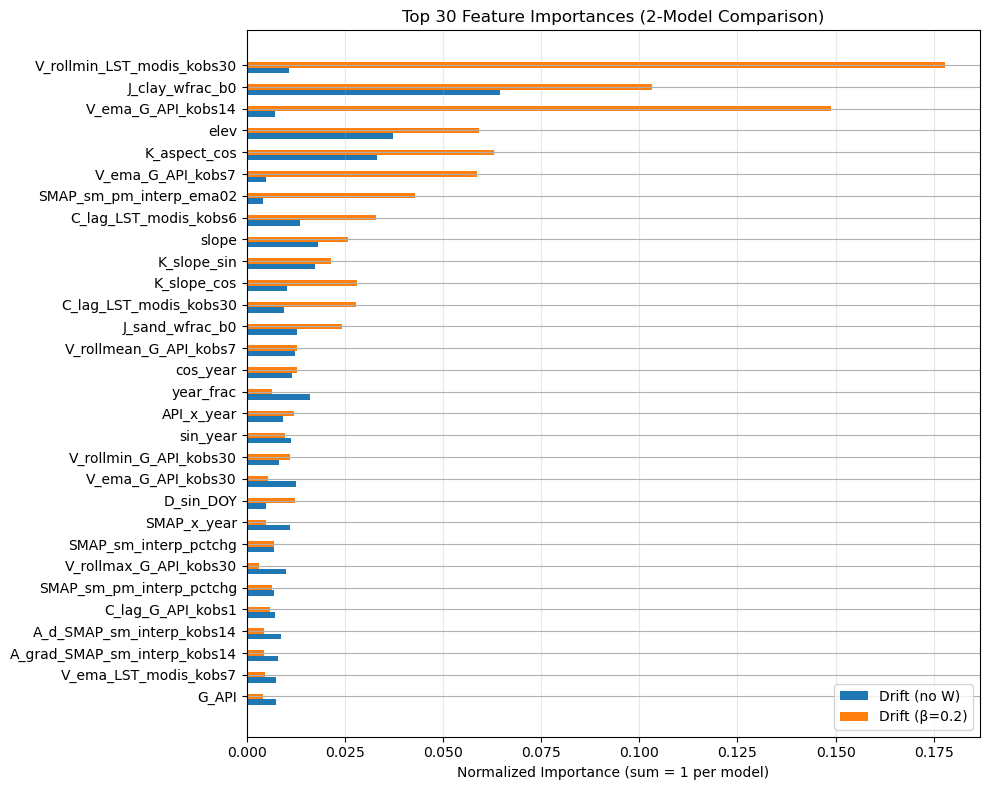

In [18]:
def get_xgb_importance(model, feature_cols):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    imp = imp / imp.sum()
    return imp

def get_rf_importance(model, feature_cols):
    rf_model = model.named_steps["model"] if hasattr(model, "named_steps") else model
    imp = pd.Series(rf_model.feature_importances_, index=feature_cols)
    imp = imp / imp.sum()
    return imp

imp_no_w = get_xgb_importance(xgb_drift_no_w_tv, FEATURE_COLS)
imp_w    = get_xgb_importance(xgb_drift_w_tv, FEATURE_COLS)

all_feats = sorted(set(imp_no_w.index) | set(imp_w.index))

cmp = pd.DataFrame({
    "drift_no_w": imp_no_w.reindex(all_feats, fill_value=0.0),
    "drift_w":    imp_w.reindex(all_feats, fill_value=0.0),
})

cmp["consensus_mean"] = cmp.mean(axis=1)

TOP_K = 30
cmp_top = cmp.sort_values("consensus_mean", ascending=False).head(TOP_K)

cmp_top_sorted = cmp_top.sort_values("consensus_mean", ascending=True)
plot_df = cmp_top_sorted[["drift_no_w", "drift_w"]]

plt.figure(figsize=(10, 8))
y = np.arange(len(plot_df))

plt.barh(y - 0.25, plot_df["drift_no_w"].values, height=0.25, label="Drift (no W)")
plt.barh(y,         plot_df["drift_w"].values,    height=0.25, label="Drift (β=0.2)")

plt.yticks(y, plot_df.index)
plt.xlabel("Normalized Importance (sum = 1 per model)")
plt.title(f"Top {TOP_K} Feature Importances (2-Model Comparison)")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
display(cmp_top)

,drift_no_w,drift_w,consensus_mean
V_rollmin_LST_modis_kobs30,0.010865,0.149062,0.079964
J_sand_wfrac_b0,0.066489,0.083464,0.074977
V_ema_G_API_kobs14,0.009666,0.124509,0.067087
K_aspect_cos,0.030735,0.101850,0.066293
J_clay_wfrac_b0,0.045153,0.066722,0.055938
elev,0.026326,0.066506,0.046416
V_rollmin_G_API_kobs30,0.007866,0.049724,0.028795
K_slope_sin,0.017502,0.036792,0.027147
V_ema_G_API_kobs7,0.005600,0.047102,0.026351
SMAP_sm_pm_interp_ema02,0.004500,0.042951,0.023726


### Residuals

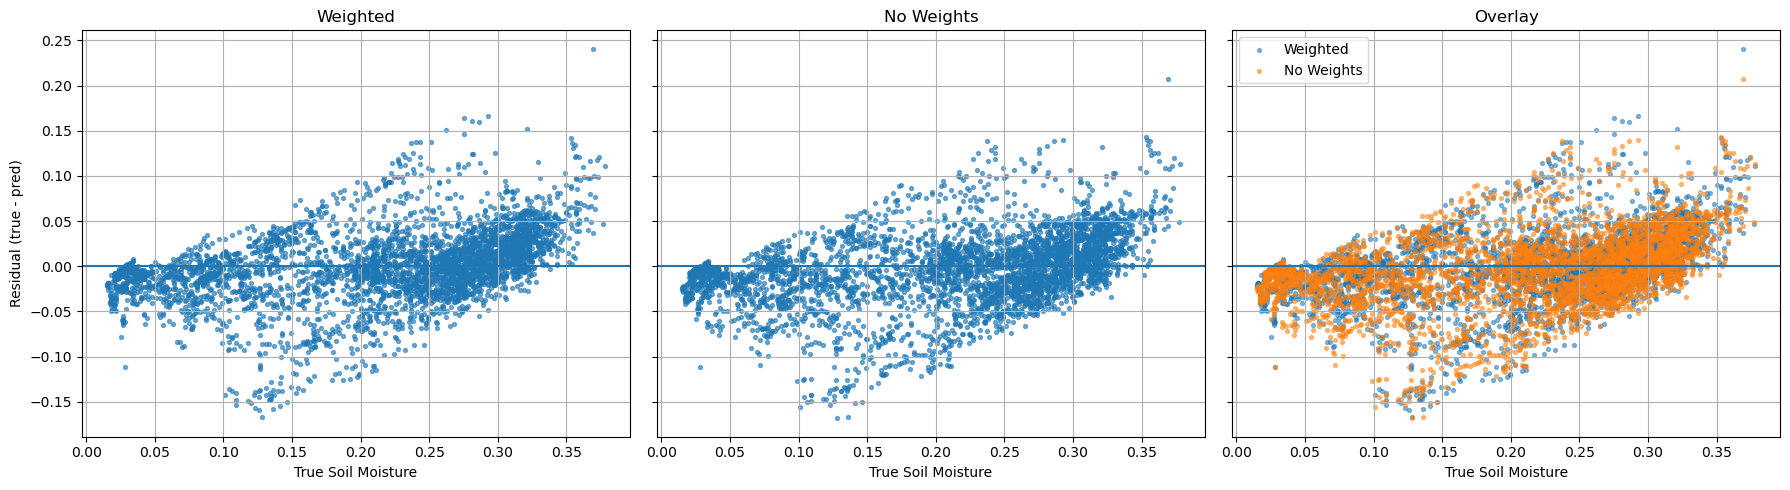

In [22]:
res_w   = y_test_d - pred_drift_test_w
res_nw  = y_test_d - pred_drift_test_no_w

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(y_test_d, res_w, s=8, alpha=0.6)
axes[0].axhline(0)
axes[0].set_xlabel("True Soil Moisture")
axes[0].set_ylabel("Residual (true - pred)")
axes[0].set_title("Weighted")

axes[1].scatter(y_test_d, res_nw, s=8, alpha=0.6)
axes[1].axhline(0)
axes[1].set_xlabel("True Soil Moisture")
axes[1].set_title("No Weights")

axes[2].scatter(y_test_d, res_w,  s=8, alpha=0.5, label="Weighted")
axes[2].scatter(y_test_d, res_nw, s=8, alpha=0.5, label="No Weights")
axes[2].axhline(0)
axes[2].set_xlabel("True Soil Moisture")
axes[2].set_title("Overlay")
axes[2].legend()

plt.tight_layout()
plt.show()

---

_Jakob Balkovec_